In [25]:
# Standard libraries
import os
import sys
from pathlib import Path
import glob
import json
import re

# =========================
# Numerical computing
# =========================
import numpy as np
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.constants as const
from scipy.interpolate import interp1d, RegularGridInterpolator
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter

# =========================
# Plotting
# =========================
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
%matplotlib inline

# =========================
# HDF5 / MATLAB / Lumerical data
# =========================
import h5py

# =========================
# Notebook display helpers
# =========================
from IPython.display import display, Markdown

In [26]:
# Plot style
# =========================
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 12,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 2,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

# Useful constants
c0 = const.c
eps0 = const.epsilon_0
mu0 = const.mu_0

# Plot the broadband focusing of the system #


Recovered peak colors:
405 nm: #3700ff, RGB = [0.21568627 0.         1.        ]
450 nm: #0413ff, RGB = [0.01568627 0.0745098  1.        ]
515 nm: #00ff90, RGB = [0.         1.         0.56431535]
635 nm: #ff000e, RGB = [1.         0.         0.05490196]
730 nm: #ff4b17, RGB = [1.         0.29249012 0.09055118]
880 nm: #c87dff, RGB = [0.78341014 0.48945148 1.        ]


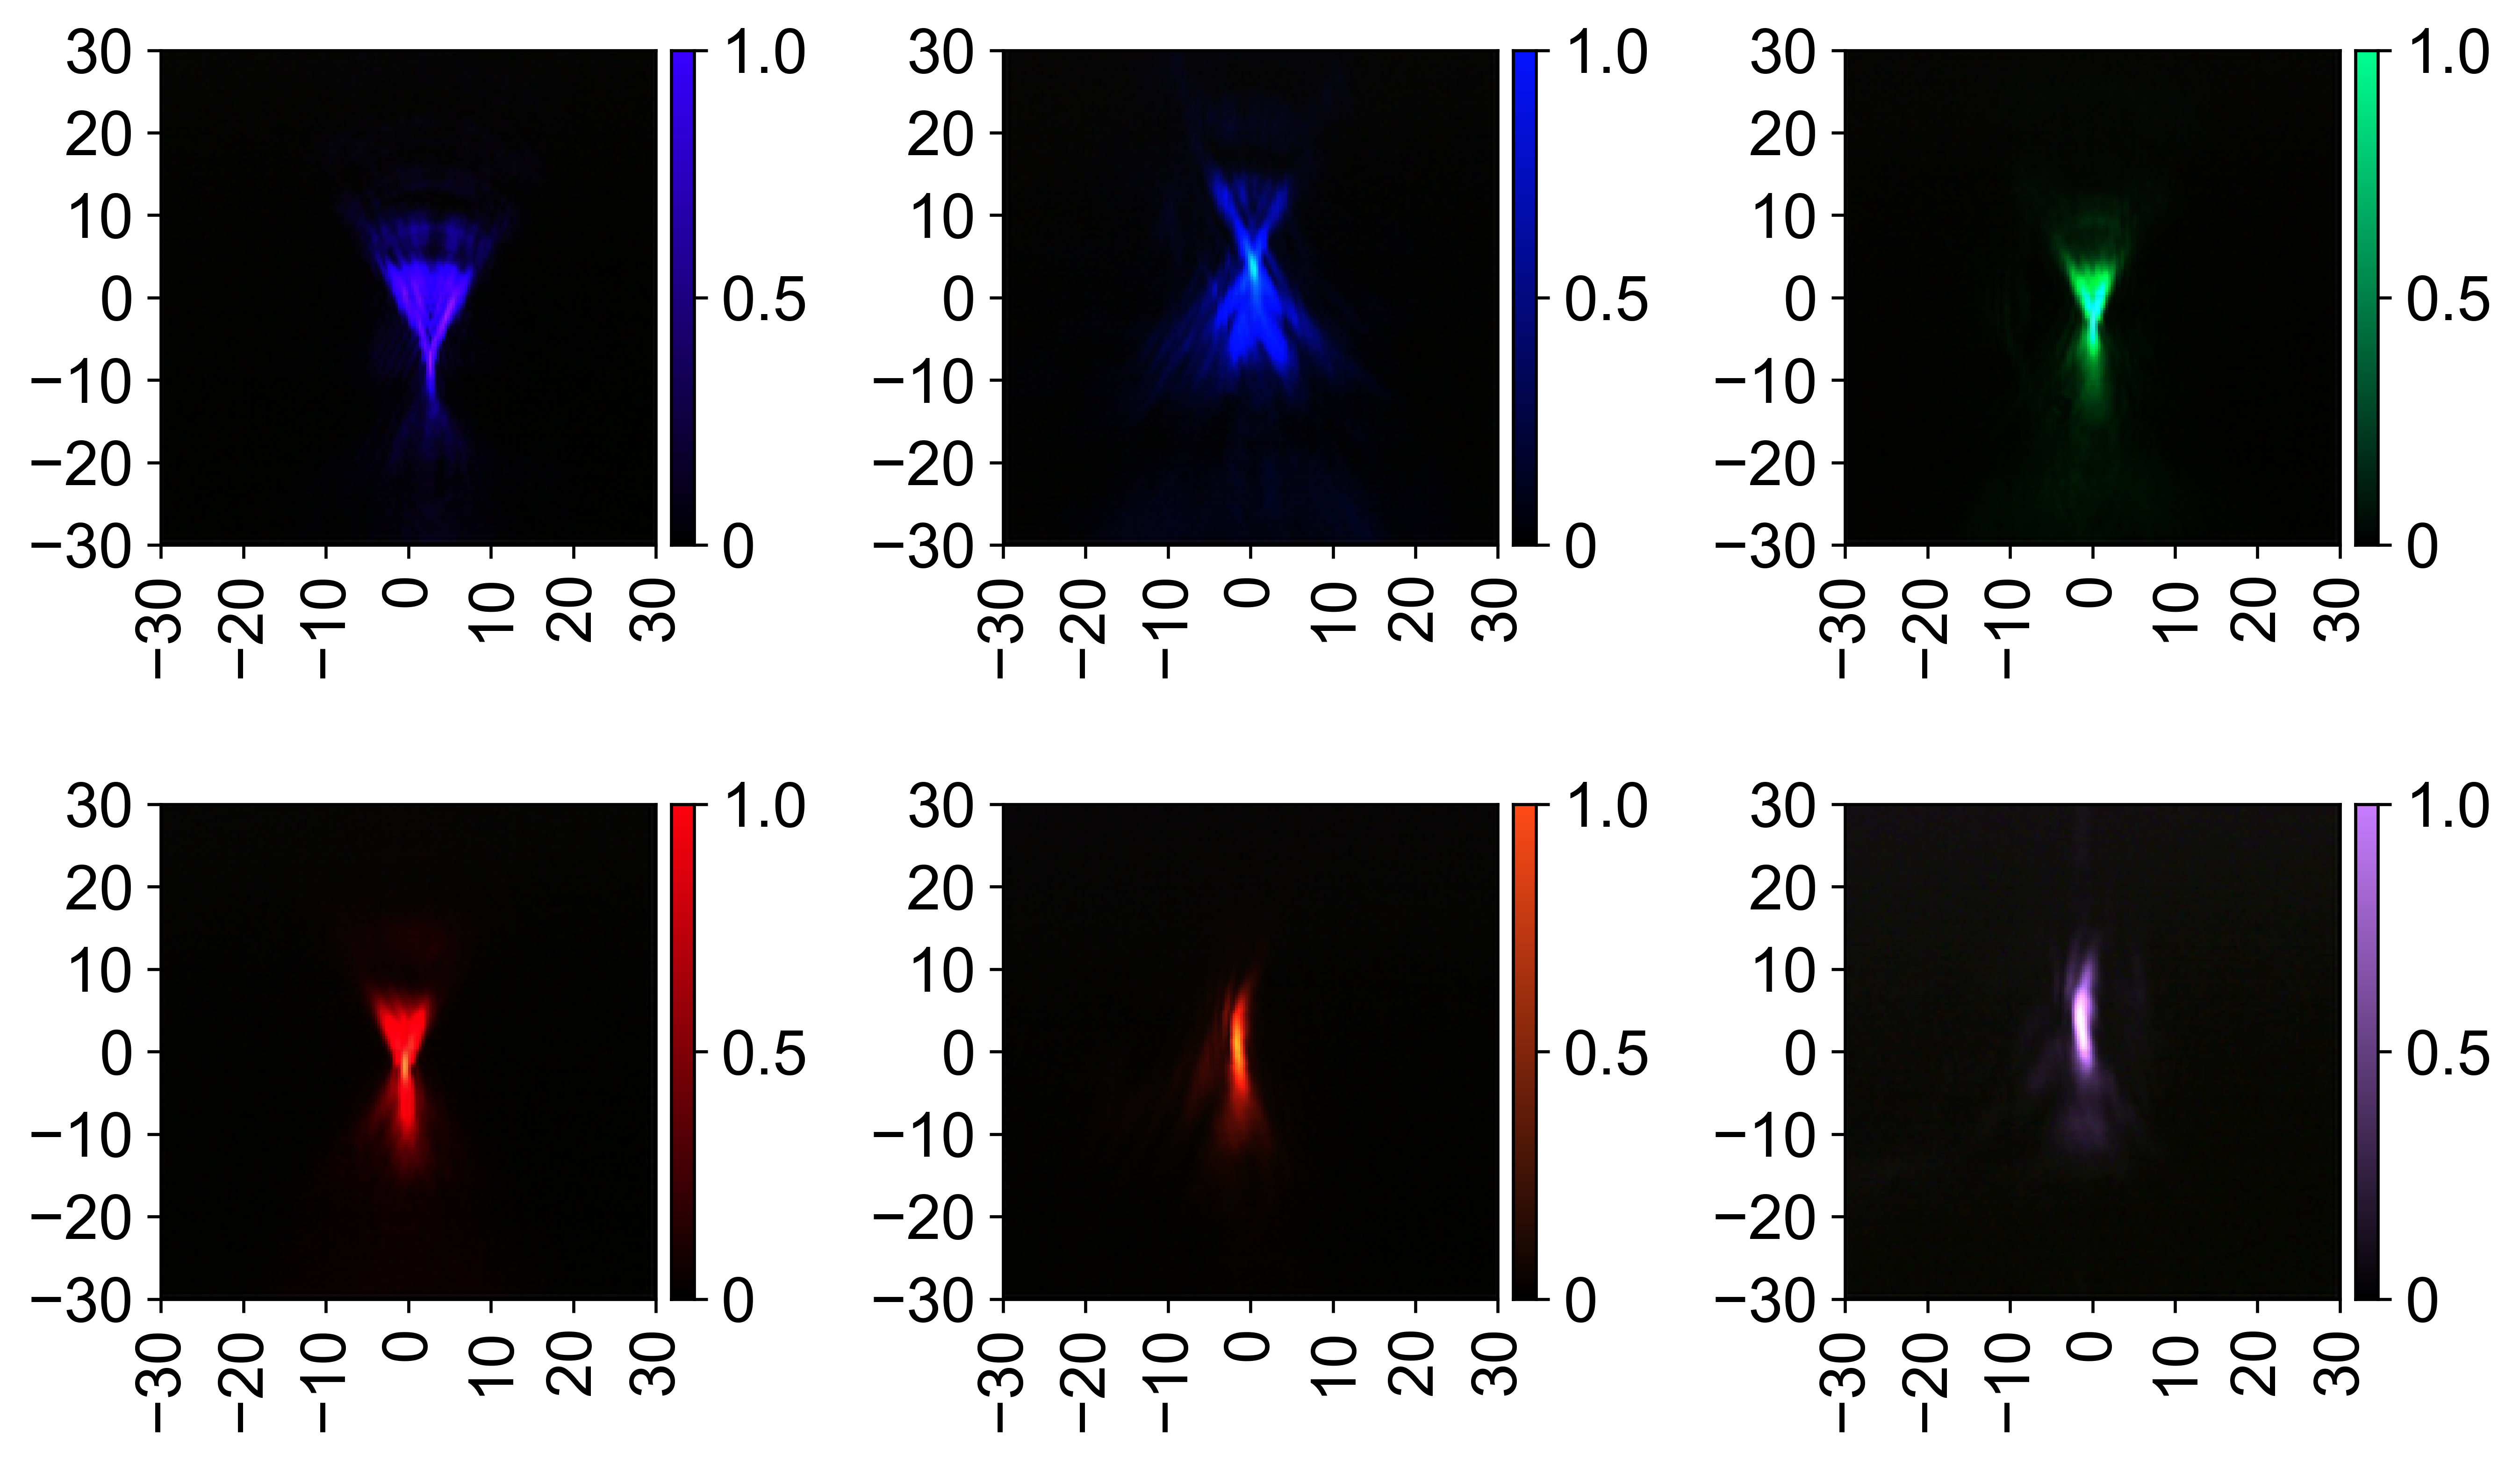

In [27]:
data = np.load("/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Paper/Gen1_Photonics/Figures/FIG2/broadband_focusing_extracted.npz")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, rgb_to_hsv
from matplotlib.patches import Rectangle


# ============================================================
# Load extracted panel(a) data
# ============================================================

wavelengths = data["wavelengths_nm"].astype(int)
rgb_uint8 = data["rgb_uint8"]      # shape: (8, H, W, 3), exact displayed RGB

# Recompute scalar intensity directly from RGB to avoid NaN issues
rgb_float = rgb_uint8.astype(float) / 255.0
I_raw = np.max(rgb_float, axis=-1)

# Normalize intensity panel-by-panel
I_norm = np.zeros_like(I_raw)

for k in range(I_raw.shape[0]):
    Ik = I_raw[k]
    Ik = Ik - np.nanmin(Ik)

    max_val = np.nanmax(Ik)
    if max_val > 0:
        Ik = Ik / max_val

    I_norm[k] = Ik


# ============================================================
# Robust colormap / peak-color recovery
# ============================================================

def recover_peak_color(rgb_panel_uint8):
    """
    Recover the dominant saturated beam color from one RGB panel.

    This rejects:
    - black background
    - gray / white pixels
    - very dim pixels
    - weakly saturated pixels
    """

    rgb = rgb_panel_uint8.astype(float) / 255.0
    flat_rgb = rgb.reshape(-1, 3)

    hsv = rgb_to_hsv(flat_rgb.reshape(1, -1, 3)).reshape(-1, 3)

    hue = hsv[:, 0]
    sat = hsv[:, 1]
    val = hsv[:, 2]

    # Main mask: bright and strongly colored pixels
    valid = (
        np.isfinite(val)
        & (val > np.percentile(val, 75))
        & (sat > 0.35)
    )

    # Relax if too few pixels are found
    if np.sum(valid) < 20:
        valid = (
            np.isfinite(val)
            & (val > np.percentile(val, 60))
            & (sat > 0.20)
        )

    # Final fallback
    if np.sum(valid) < 5:
        valid = (
            np.isfinite(val)
            & (val > np.percentile(val, 50))
            & (sat > 0.10)
        )

    if np.sum(valid) == 0:
        raise RuntimeError("No valid colored pixels found.")

    # Score favors saturated and bright pixels
    score = sat * val

    valid_score = score[valid]

    # Use top colored pixels, not necessarily the absolute brightest pixels
    cutoff = np.percentile(valid_score, 98)
    selected = valid & (score >= cutoff)

    if np.sum(selected) < 5:
        cutoff = np.percentile(valid_score, 95)
        selected = valid & (score >= cutoff)

    selected_rgb = flat_rgb[selected]

    # Normalize each selected pixel by its own maximum channel
    selected_rgb = selected_rgb / np.maximum(
        selected_rgb.max(axis=1, keepdims=True),
        1e-12,
    )

    # Robust representative color
    peak_rgb = np.median(selected_rgb, axis=0)

    # Normalize so the strongest channel is 1
    peak_rgb = peak_rgb / np.maximum(np.max(peak_rgb), 1e-12)

    return peak_rgb

peak_rgb = {}

for k, wl in enumerate(wavelengths):
    try:
        peak_rgb[wl] = recover_peak_color(rgb_uint8[k])
    except RuntimeError:
        print(f"Warning: could not recover color for {wl} nm. Using fallback.")
        fallback_colors = {
            405: np.array([0.23, 0.00, 1.00]),
            450: np.array([0.02, 0.10, 1.00]),
            515: np.array([0.00, 1.00, 0.35]),
            635: np.array([1.00, 0.00, 0.05]),
            730: np.array([1.00, 0.13, 0.06]),
            830: np.array([0.92, 0.43, 1.00]),
            880: np.array([0.78, 0.50, 1.00]),
            940: np.array([0.75, 0.45, 1.00]),
        }
        peak_rgb[wl] = fallback_colors[wl]

selected_wavelengths = np.array([405, 450, 515, 635, 730, 880])
selected_indices = [np.where(wavelengths == wl)[0][0] for wl in selected_wavelengths]

print("Recovered peak colors:")
for wl in selected_wavelengths:
    color = peak_rgb[wl]
    color_uint8 = np.clip(np.round(color * 255), 0, 255).astype(int)
    hex_color = "#{:02x}{:02x}{:02x}".format(*color_uint8)
    print(f"{wl} nm: {hex_color}, RGB = {color}")

fig, axes = plt.subplots(
    2, 3,
    figsize=(10.2, 6.2),
    dpi=600,
    constrained_layout=False,
)

for ax, idx, wl in zip(axes.ravel(), selected_indices, selected_wavelengths):
    cmap = LinearSegmentedColormap.from_list(
        f"{wl}_cmap",
        [(0.0, "black"), (1.0, peak_rgb[wl])],
    )

    ax.imshow(
        rgb_uint8[idx],
        extent=[-30, 30, -30, 30],
        origin="upper",
        interpolation="nearest",
    )

    ax.set_xlim(-30, 30)
    ax.set_ylim(-30, 30)
    ax.set_aspect("equal")

    ax.set_xticks([-30, -20, -10, 0, 10, 20, 30])
    ax.set_yticks([-30, -20, -10, 0, 10, 20, 30])

    ax.tick_params(axis="both", labelsize=16)
    ax.tick_params(axis="x", labelrotation=90)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4.6%", pad=0.055)
    n_colorbar_steps = 512
    for step in range(n_colorbar_steps):
        y0 = step / n_colorbar_steps
        y1 = (step + 1) / n_colorbar_steps
        color = cmap((step + 0.5) / n_colorbar_steps)
        cax.add_patch(
            Rectangle(
                (0, y0),
                1,
                (y1 - y0) + 1e-3,
                facecolor=color,
                edgecolor="none",
                linewidth=0,
                antialiased=False,
            )
        )
    cax.set_xlim(0, 1)
    cax.set_ylim(0, 1)
    cax.set_xticks([])
    cax.set_yticks([0, 0.5, 1.0])
    cax.set_yticklabels(["0", "0.5", "1.0"])
    cax.yaxis.tick_right()
    cax.yaxis.set_label_position("right")
    cax.tick_params(axis="y", labelsize=16)

fig.subplots_adjust(wspace=0.58, hspace=0.35)
plt.show()



   wavelength_nm  radial_fwhm_um  axial_fwhm_um
0            405            4.10           0.67
1            450            4.50           0.79
2            515            7.91           1.12
3            635            5.61           1.01
4            730            7.61           1.24
5            880            6.71           1.46


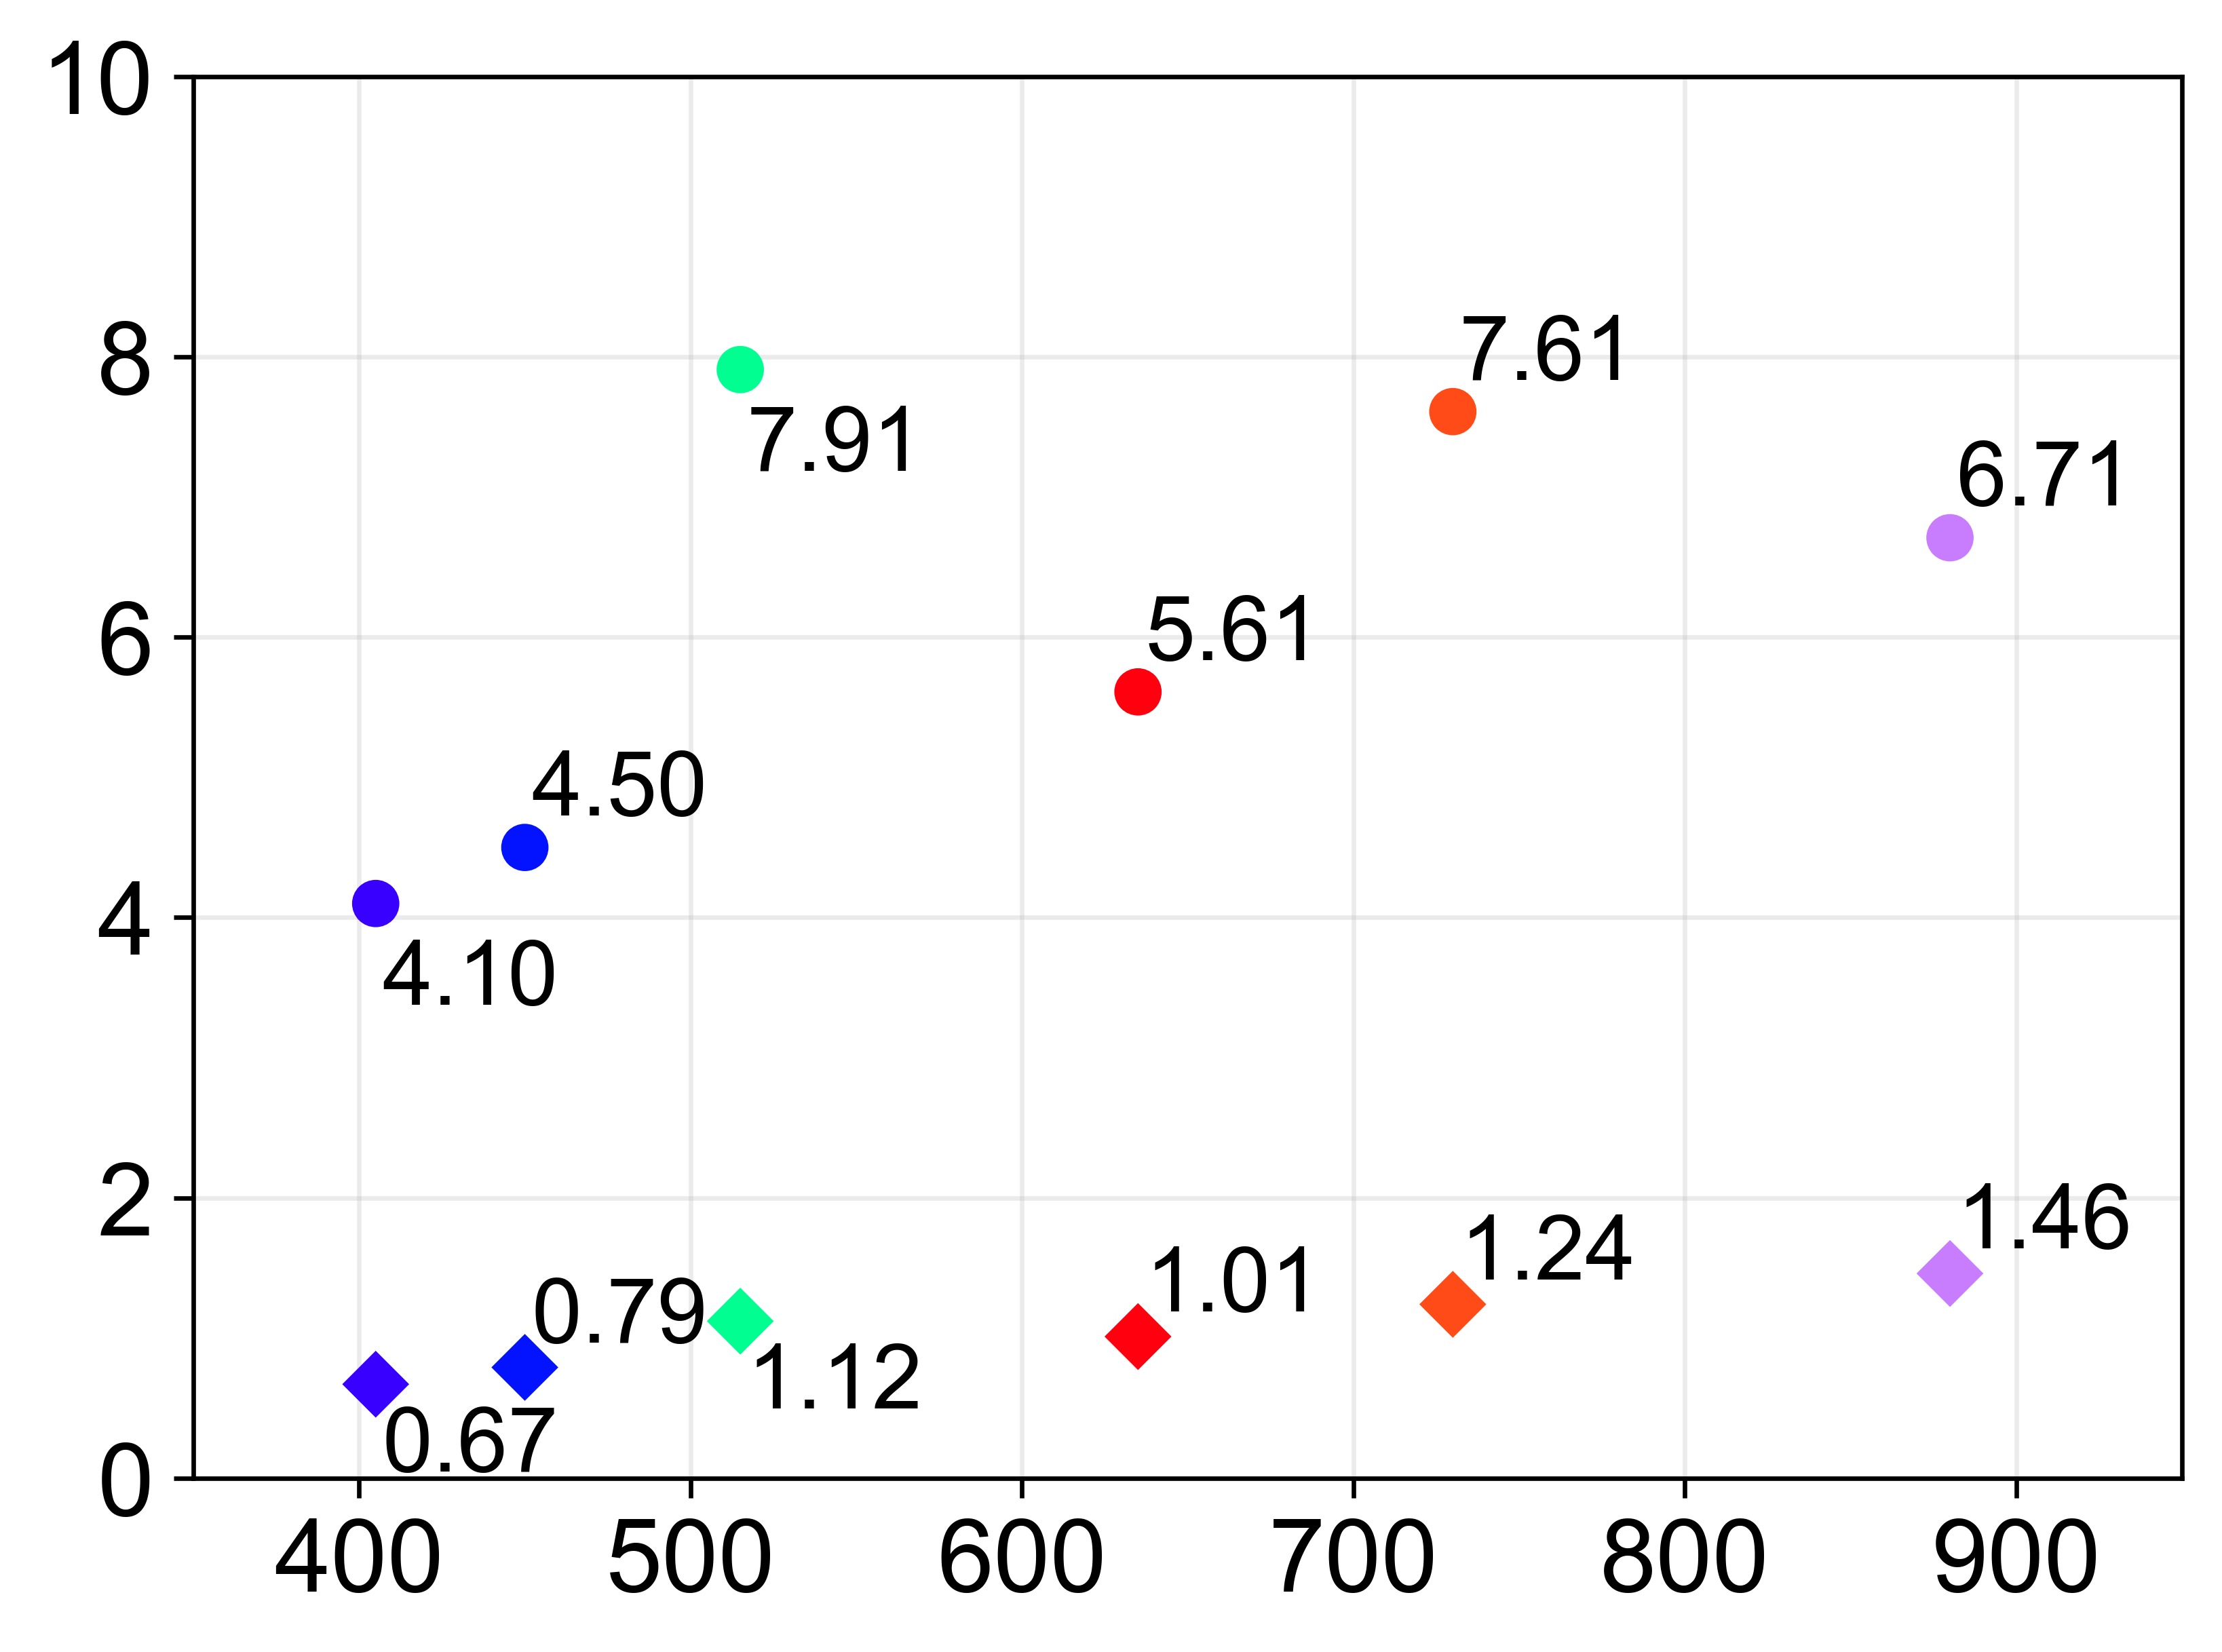

In [28]:
#fig. b
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Extracted data from panel (b)
# Numeric values are taken from the labels in the original plot
# ============================================================

wavelength_nm = np.array([405, 450, 515, 635, 730, 880], dtype=float)

radial_fwhm_um = np.array([4.10, 4.50, 7.91, 5.61, 7.61, 6.71], dtype=float)
axial_fwhm_um  = np.array([0.67, 0.79, 1.12, 1.01, 1.24, 1.46], dtype=float)

# Save extracted data
df = pd.DataFrame({
    "wavelength_nm": wavelength_nm.astype(int),
    "radial_fwhm_um": radial_fwhm_um,
    "axial_fwhm_um": axial_fwhm_um,
})

df.to_csv("panel_b_extracted_mode_size.csv", index=False)
print(df)

# ============================================================
# Plot settings
# ============================================================

fallback_colors = {
    405: "#7a00ff",
    450: "#1762ff",
    515: "#00a51a",
    635: "#ff4a0a",
    730: "#d90000",
    880: "#000000",
}

colors = {
    int(wl): peak_rgb[int(wl)] if "peak_rgb" in globals() else fallback_colors[int(wl)]
    for wl in wavelength_nm
}

color_list = [colors[int(wl)] for wl in wavelength_nm]

fig, ax = plt.subplots(figsize=(5.8, 4.4), dpi=600)

# ============================================================
# Scatter plot
# ============================================================

for wl, radial, axial, color in zip(
    wavelength_nm,
    radial_fwhm_um,
    axial_fwhm_um,
    color_list,
):
    ax.scatter(
        wl,
        radial,
        s=70,
        marker="o",
        color=color,
        edgecolor="none",
        zorder=3,
        label="Radial" if wl == wavelength_nm[0] else None,
    )

    ax.scatter(
        wl,
        axial,
        s=70,
        marker="D",
        color=color,
        edgecolor="none",
        zorder=3,
        label="Axial" if wl == wavelength_nm[0] else None,
    )

# ============================================================
# Optional numeric labels
# Comment this whole section out if you do not want labels
# ============================================================

for wl, radial, axial in zip(wavelength_nm, radial_fwhm_um, axial_fwhm_um):

    if wl in [405, 515]:
        radial_offset = -0.55
        axial_offset = -0.45
    else:
        radial_offset = 0.40
        axial_offset = 0.35

    ax.text(
        wl + 2,
        radial + radial_offset,
        f"{radial:.2f}",
        fontsize=16,
        ha="left",
        va="center",
    )

    ax.text(
        wl + 2,
        axial + axial_offset,
        f"{axial:.2f}",
        fontsize=16,
        ha="left",
        va="center",
    )

# ============================================================
# Axes formatting
# ============================================================

ax.set_xlim(350, 950)
ax.set_ylim(0, 10)

ax.set_xticks([400, 500, 600, 700, 800, 900])
ax.set_yticks([0, 2, 4, 6, 8, 10])

ax.grid(True, which="major", alpha=0.25)
ax.tick_params(axis="both", labelsize=18)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

# legend = ax.legend(
#     loc="center right",
#     frameon=True,
#     fontsize=18,
#     fancybox=False,
# )

# legend.get_frame().set_edgecolor("0.5")
# legend.get_frame().set_linewidth(0.8)
# for text in legend.get_texts():
#     text.set_color("black")
#     text.set_fontfamily("Arial")

# for handle in legend.legendHandles:
#     handle.set_color("black")
#     handle.set_facecolor("black")
#     handle.set_edgecolor("black")

fig.tight_layout()

plt.show()

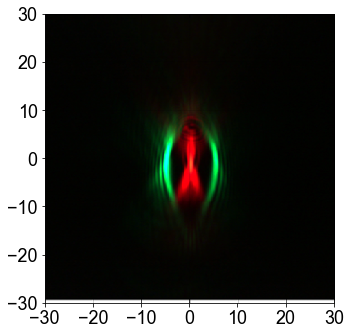

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load extracted NPZ file
# ============================================================
npz_path = "/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Paper/Gen1_Photonics/Figures/FIG2/extracted_2d_profile_rgb_grid.npz"
# If using ChatGPT sandbox:
# npz_path = "/mnt/data/extracted_2d_profile_rgb_grid.npz"

data = np.load(npz_path)

x_um = data["x_um"]
y_um = data["y_um"]
rgb_uint8 = data["rgb_uint8"]

# Optional extracted arrays
R = data["R_uint8"]
G = data["G_uint8"]
B = data["B_uint8"]
intensity = data["intensity"]
intensity_norm = data["intensity_norm"]

# ============================================================
# Plot using original extracted RGB colors
# ============================================================
plt.figure(figsize=(6, 5))

plt.imshow(
    rgb_uint8,
    extent=[x_um.min(), x_um.max(), y_um.min(), y_um.max()],
    origin="upper",
    aspect="equal",
    interpolation="nearest"
)

plt.xlim(-30, 30)
plt.ylim(-30, 30)
plt.xticks([-30, -20, -10, 0, 10, 20, 30])
plt.yticks([-30, -20, -10, 0, 10, 20, 30])
plt.tick_params(axis="both", labelsize=18)

plt.tight_layout()
plt.show()

Simulated y at x = -5: -30.605 dB
Measured y at x = -5: -27.113 dB
Simulated y at x = 5: -33.105 dB
Measured y at x = 5: -27.870 dB


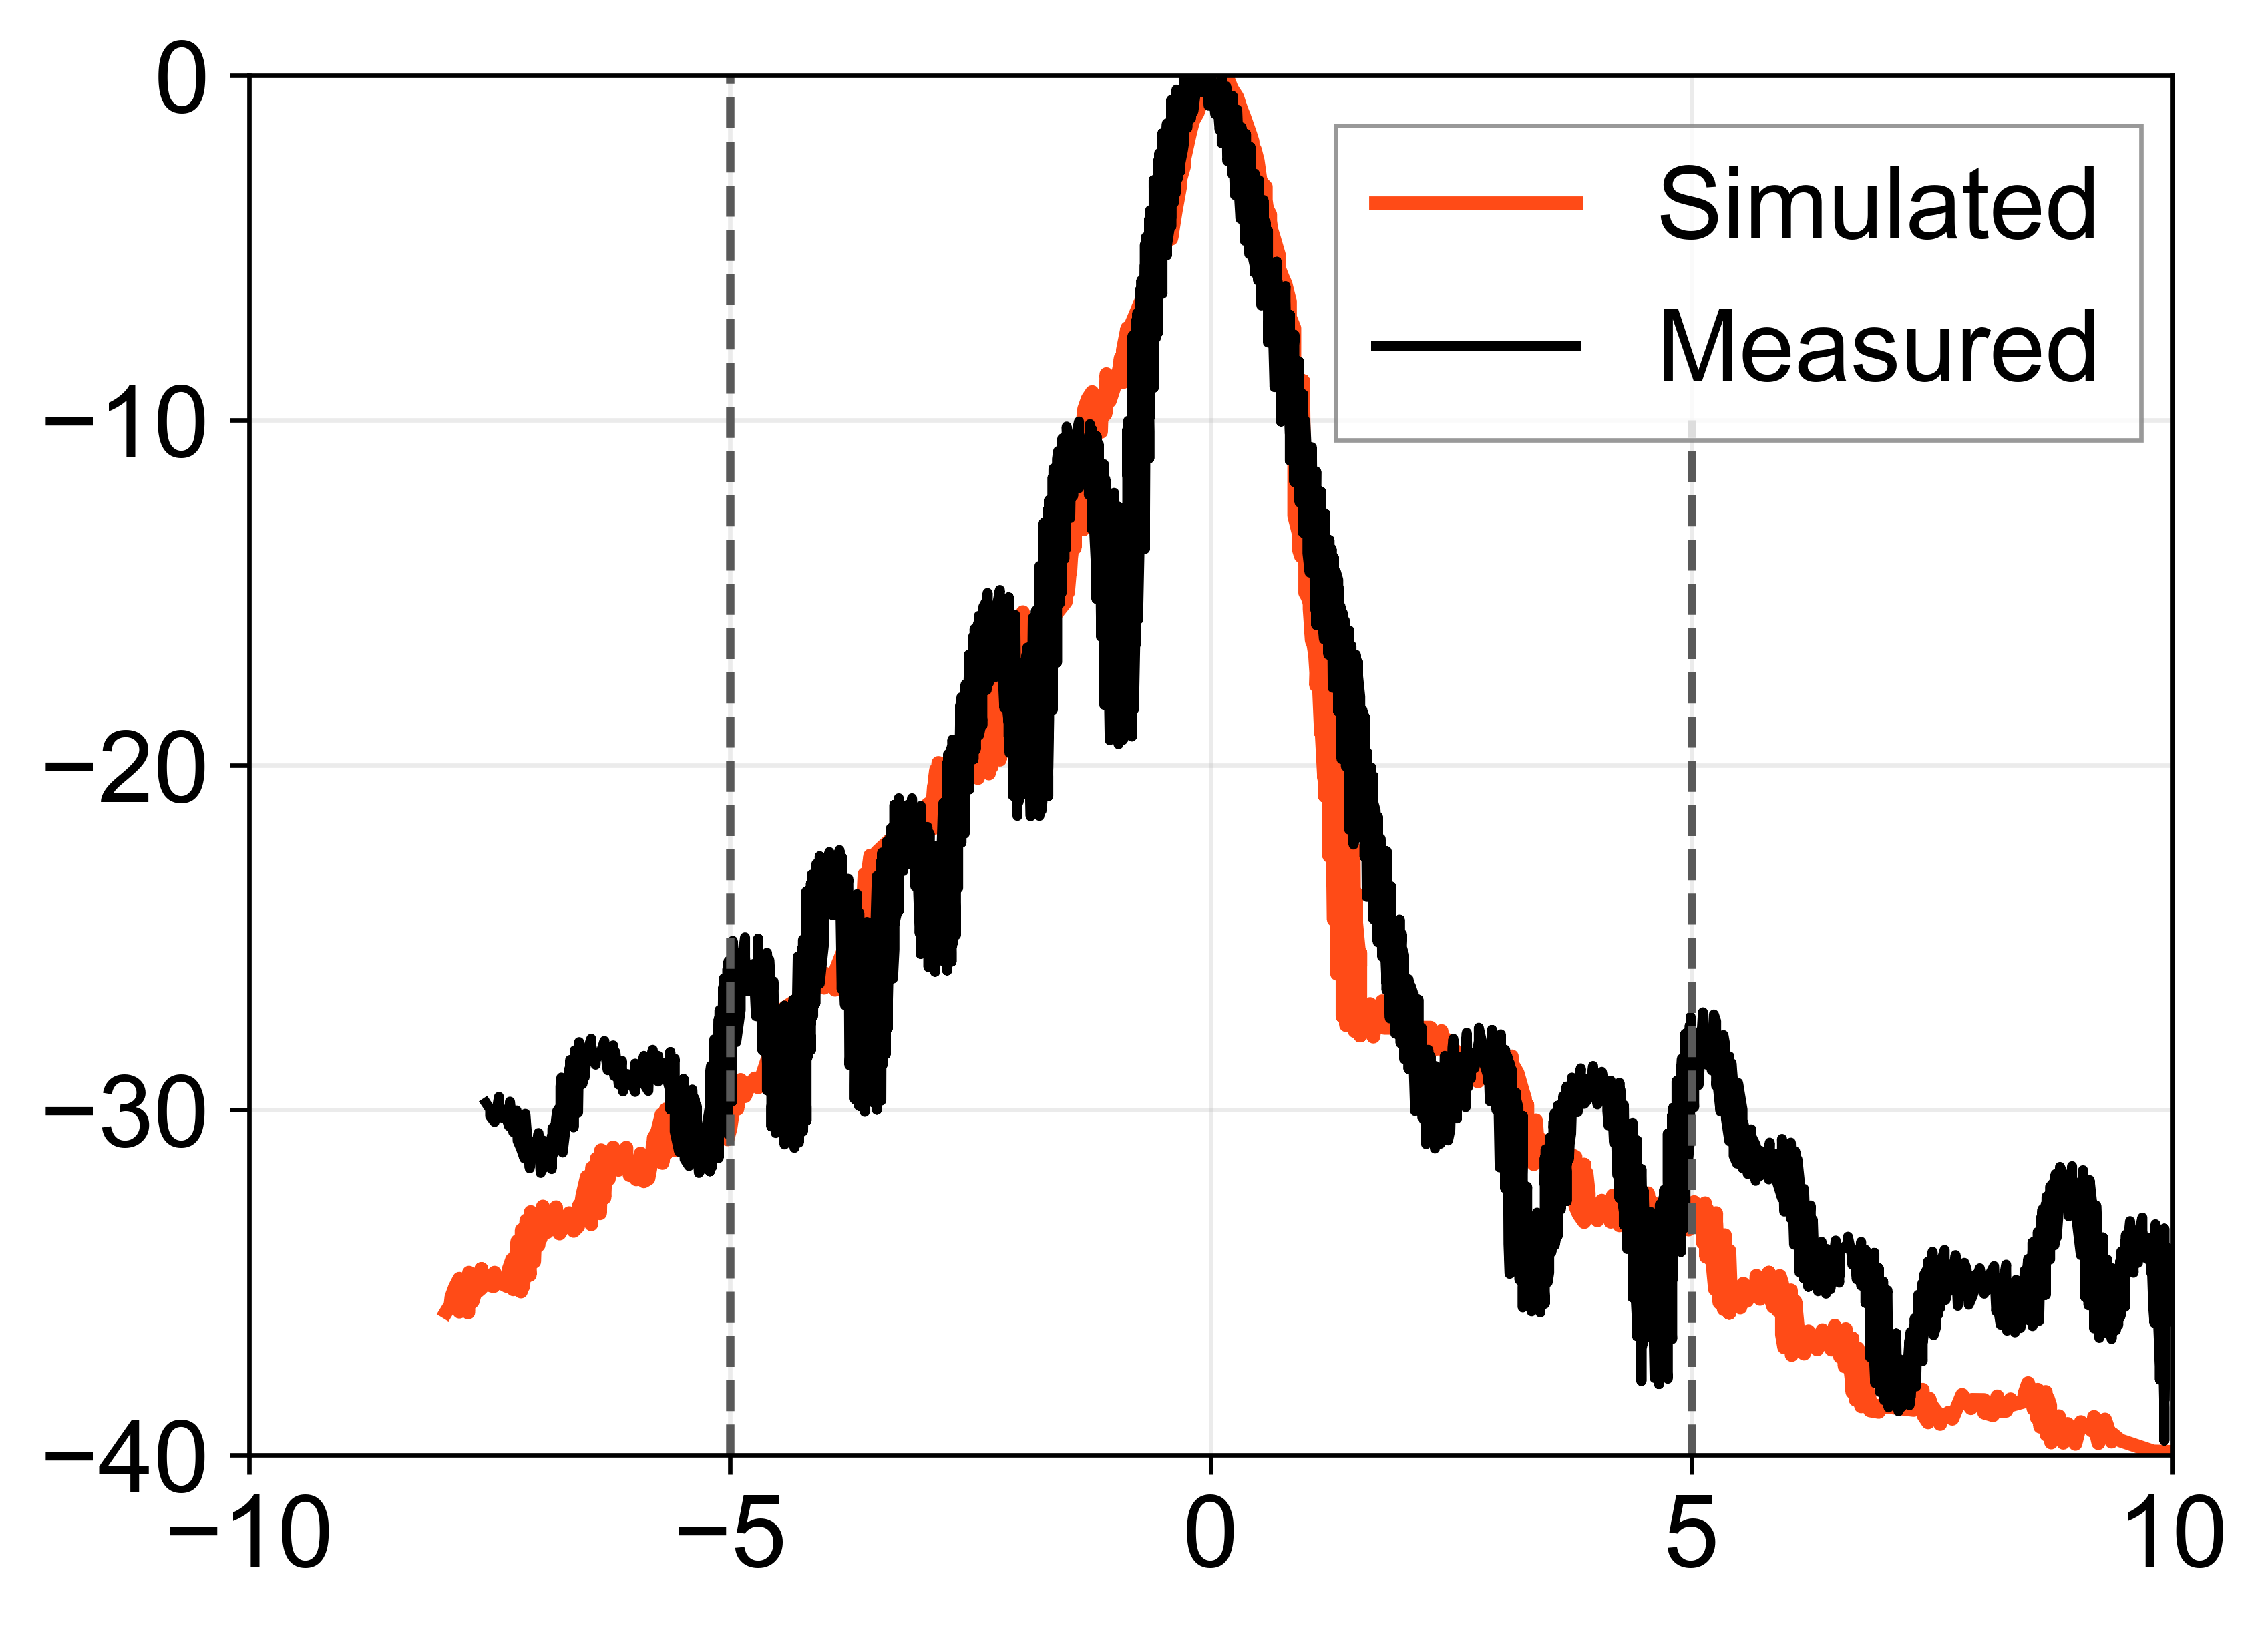

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# ============================================================
# File paths
# ============================================================
sim_path = Path("/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Paper/Gen1_Photonics/Figures/FIG2/730_simulated.csv")
meas_path = Path("/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Paper/Gen1_Photonics/Figures/FIG2/730_measured.csv")

# If using ChatGPT sandbox, use:
# sim_path = Path("/mnt/data/730_simulated.csv")
# meas_path = Path("/mnt/data/730_measured.csv")

# ============================================================
# Load CSV files
# No header: each file has two columns:
# column 0 = axial position, column 1 = amplitude in dB
# ============================================================
sim = pd.read_csv(sim_path, header=None, names=["x_um", "amplitude_dB"])
meas = pd.read_csv(meas_path, header=None, names=["x_um", "amplitude_dB"])

# Clean and sort
sim["x_um"] = pd.to_numeric(sim["x_um"], errors="coerce")
sim["amplitude_dB"] = pd.to_numeric(sim["amplitude_dB"], errors="coerce")

meas["x_um"] = pd.to_numeric(meas["x_um"], errors="coerce")
meas["amplitude_dB"] = pd.to_numeric(meas["amplitude_dB"], errors="coerce")

sim = sim.dropna().sort_values("x_um").reset_index(drop=True)
meas = meas.dropna().sort_values("x_um").reset_index(drop=True)

x_queries = np.array([-5, 5])
sim_y_at_queries = np.interp(x_queries, sim["x_um"], sim["amplitude_dB"])
meas_y_at_queries = np.interp(x_queries, meas["x_um"], meas["amplitude_dB"])

for x_query, sim_y, meas_y in zip(x_queries, sim_y_at_queries, meas_y_at_queries):
    print(f"Simulated y at x = {x_query:g}: {sim_y:.3f} dB")
    print(f"Measured y at x = {x_query:g}: {meas_y:.3f} dB")

sim_color_730 = peak_rgb[730] if "peak_rgb" in globals() else np.array([1.00, 0.13, 0.06])

# ============================================================
# Plot overlay
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4.4), dpi=600)

ax.plot(
    sim["x_um"],
    sim["amplitude_dB"],
    color=sim_color_730,
    linestyle="-",
    linewidth=2.5,
    label="Simulated"
)

ax.plot(
    meas["x_um"],
    meas["amplitude_dB"],
    "k-",
    linewidth=1.8,
    label="Measured"
)

ax.axvline(-5, color="0.35", linestyle="--", linewidth=1.5)
ax.vlines(5, ymin=-40, ymax=-10, color="0.35", linestyle="--", linewidth=1.5)

ax.set_xlim(-10, 10)
ax.set_ylim(-40, 0)

# ax.axhline(-30, color="0.35", linestyle="--", linewidth=1.5)

ax.grid(True, alpha=0.25)
ax.tick_params(axis="both", labelsize=18)
legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    fontsize=18,
    prop={"family": "Arial", "size": 18},
    fancybox=False,
)

legend.get_frame().set_edgecolor("0.5")
legend.get_frame().set_linewidth(0.8)

fig.tight_layout()
plt.show()

Simulated y at x = -5: -32.680 dB
Measured y at x = -5: -23.608 dB
Simulated y at x = 5: -34.479 dB
Measured y at x = 5: -31.608 dB


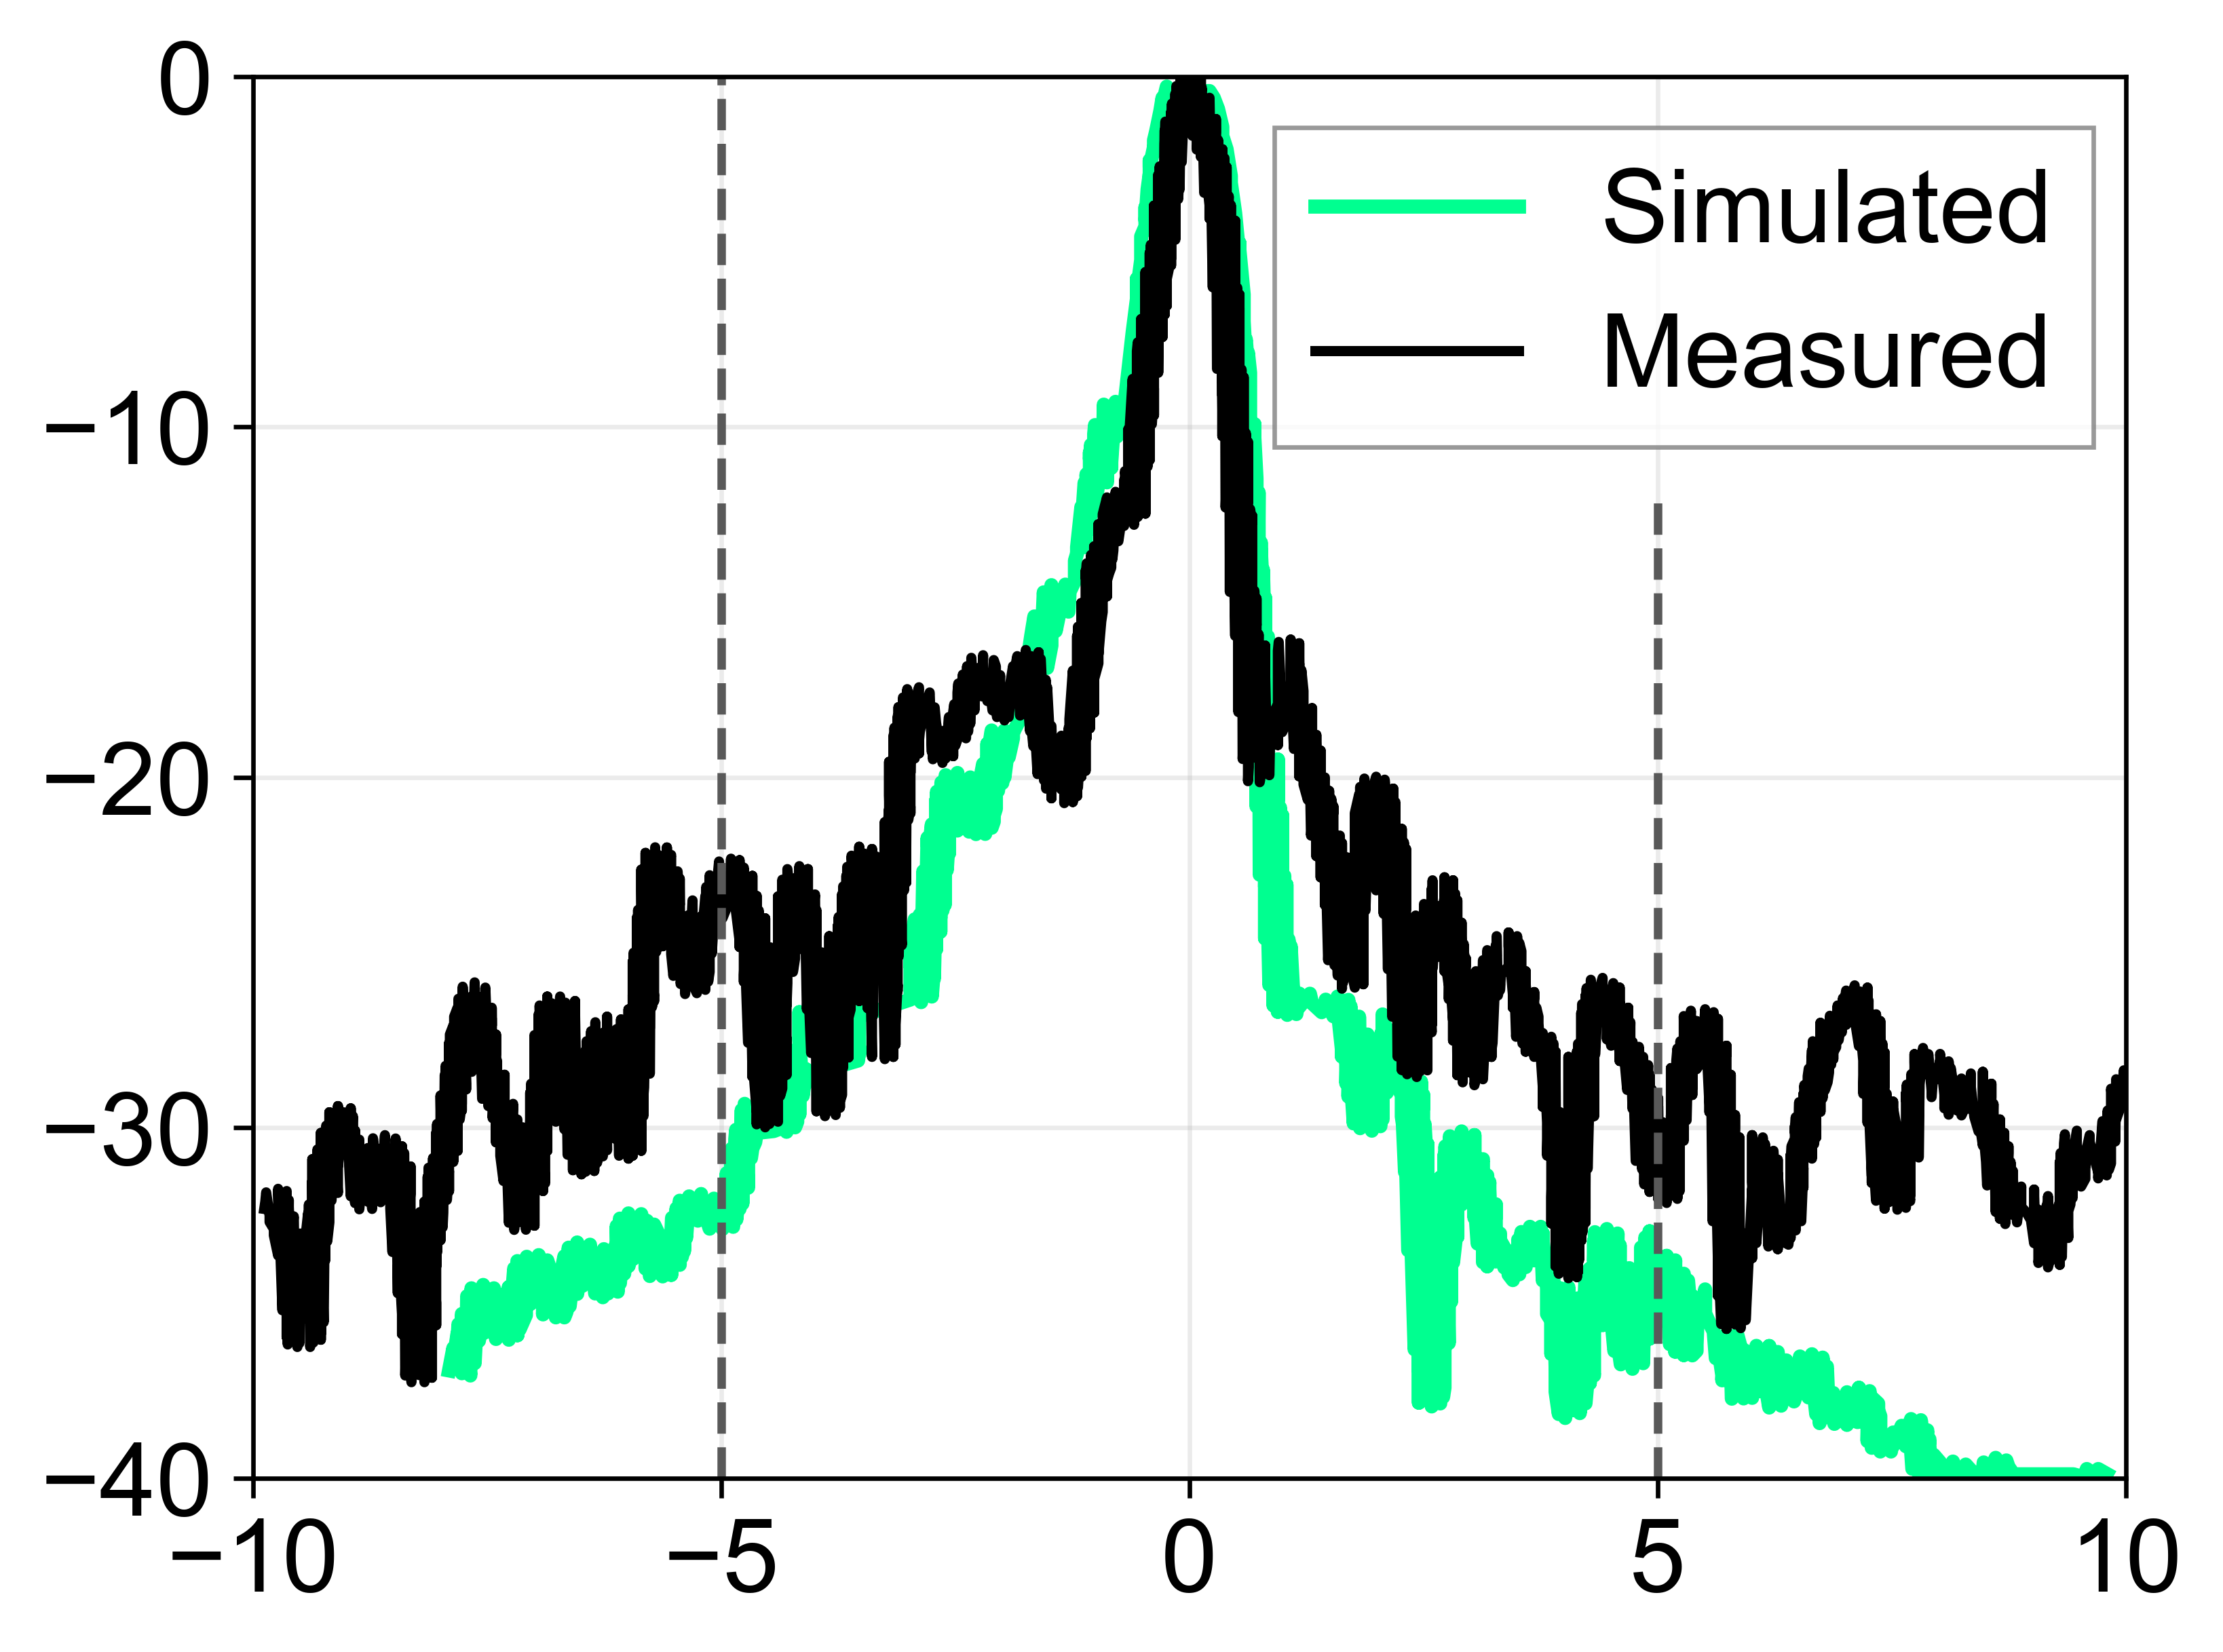

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# ============================================================
# File paths
# ============================================================
sim_path = Path("/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Paper/Gen1_Photonics/Figures/FIG2/515_simulated.csv")
meas_path = Path("/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Paper/Gen1_Photonics/Figures/FIG2/515_measured.csv")

# ============================================================
# Load CSV files
# No header: each file has two columns:
# column 0 = axial position, column 1 = amplitude in dB
# ============================================================
sim = pd.read_csv(sim_path, header=None, names=["x_um", "amplitude_dB"])
meas = pd.read_csv(meas_path, header=None, names=["x_um", "amplitude_dB"])

sim["x_um"] = pd.to_numeric(sim["x_um"], errors="coerce")
sim["amplitude_dB"] = pd.to_numeric(sim["amplitude_dB"], errors="coerce")

meas["x_um"] = pd.to_numeric(meas["x_um"], errors="coerce")
meas["amplitude_dB"] = pd.to_numeric(meas["amplitude_dB"], errors="coerce")

sim = sim.dropna().sort_values("x_um").reset_index(drop=True)
meas = meas.dropna().sort_values("x_um").reset_index(drop=True)

x_queries = np.array([-5, 5])
sim_y_at_queries = np.interp(x_queries, sim["x_um"], sim["amplitude_dB"])
meas_y_at_queries = np.interp(x_queries, meas["x_um"], meas["amplitude_dB"])

for x_query, sim_y, meas_y in zip(x_queries, sim_y_at_queries, meas_y_at_queries):
    print(f"Simulated y at x = {x_query:g}: {sim_y:.3f} dB")
    print(f"Measured y at x = {x_query:g}: {meas_y:.3f} dB")

sim_color_515 = peak_rgb[515] if "peak_rgb" in globals() else np.array([0.00, 1.00, 0.35])

# ============================================================
# Plot overlay
# ============================================================
fig, ax = plt.subplots(figsize=(5.8, 4.4), dpi=600)

ax.plot(
    sim["x_um"],
    sim["amplitude_dB"],
    color=sim_color_515,
    linestyle="-",
    linewidth=2.5,
    label="Simulated"
)

ax.plot(
    meas["x_um"],
    meas["amplitude_dB"],
    "k-",
    linewidth=1.8,
    label="Measured"
)

ax.axvline(-5, color="0.35", linestyle="--", linewidth=1.5)
ax.vlines(5, ymin=-40, ymax=-12, color="0.35", linestyle="--", linewidth=1.5)

ax.set_xlim(-10, 10)
ax.set_ylim(-40, 0)

ax.grid(True, alpha=0.25)
ax.tick_params(axis="both", labelsize=18)
legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    fontsize=18,
    prop={"family": "Arial", "size": 18},
    fancybox=False,
)

legend.get_frame().set_edgecolor("0.5")
legend.get_frame().set_linewidth(0.8)

fig.tight_layout()
plt.show()

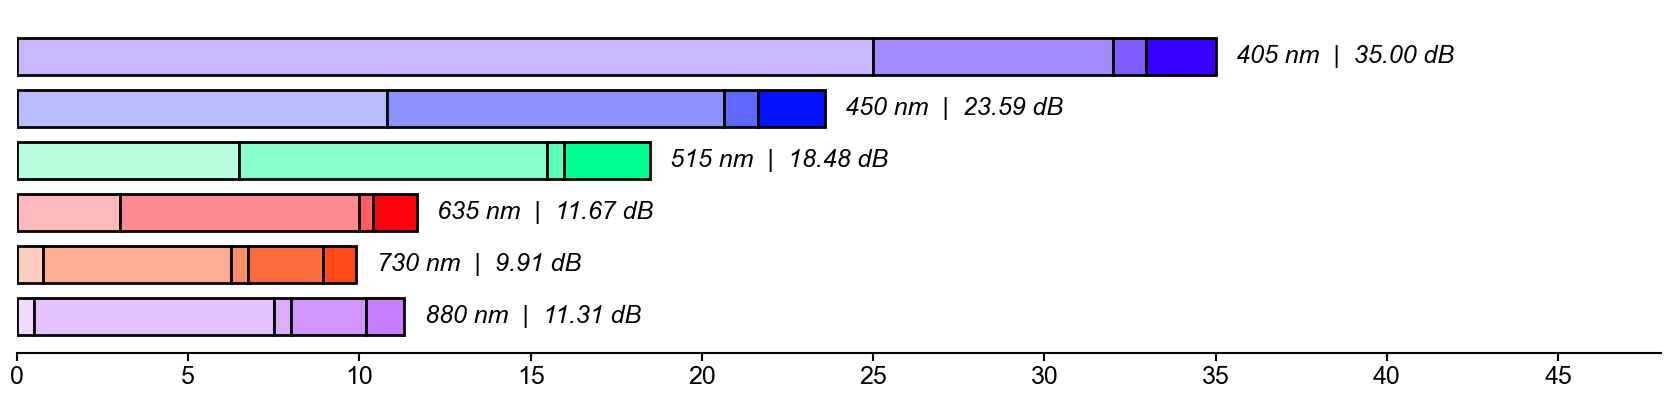

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# ============================================================
# Extracted directly from loss_sources.xlsx
# ============================================================

wl = np.array([405, 450, 515, 635, 730, 880])

source_names = [
    "Propagation",
    "Optical I/O",
    "Bending",
    "WDM",
    r"$\mu$-optics",
]

# Rows = wavelengths
# Columns = loss sources:
# Propagation, Optical I/O, Bending, WDM, µ-optics
loss_mat = np.array([
    [24.99,              7.00,              0.98,              0.00, 2.03],
    [10.812083333333334, 9.829166666666667, 0.982916666666667, 0.00, 1.965833333333334],
    [6.492972972972973,  8.990270270270271, 0.499459459459460, 0.00, 2.497297297297297],
    [3.00,               7.00,              0.40,              0.00, 1.27],
    [0.75,               5.50,              0.50,              2.20, 0.96],
    [0.50,               7.00,              0.50,              2.20, 1.11],
])

total_loss = np.sum(loss_mat, axis=1)

# ============================================================
# Style settings
# ============================================================

fnts = 18
lw = 2.0
bar_h = 0.70
font_name = "Arial"

# ============================================================
# Color scheme
# ============================================================

fallback_peak_rgb = {
    405: np.array([0.23, 0.00, 1.00]),
    450: np.array([0.02, 0.10, 1.00]),
    515: np.array([0.00, 1.00, 0.35]),
    635: np.array([1.00, 0.00, 0.05]),
    730: np.array([1.00, 0.13, 0.06]),
    880: np.array([0.78, 0.50, 1.00]),
}

def make_wavelength_shades(base_rgb, n_shades):
    base_rgb = np.asarray(base_rgb, dtype=float)
    white_mix = np.linspace(0.72, 0.00, n_shades)
    shades = (1 - white_mix[:, None]) * base_rgb[None, :] + white_mix[:, None]
    shades[-1] = base_rgb
    return np.clip(shades, 0, 1)

color_cell = []

for wavelength in wl:
    wavelength = int(wavelength)
    base_rgb = peak_rgb[wavelength] if "peak_rgb" in globals() else fallback_peak_rgb[wavelength]
    color_cell.append(make_wavelength_shades(base_rgb, len(source_names)))

# ============================================================
# Plot
# ============================================================

# MATLAB figure size:
# Position = [100 100 1550*1.1 780/1.8]
fig_w_px = 1550 * 1.1
fig_h_px = 780 / 1.8
dpi_display = 100

fig, ax = plt.subplots(
    figsize=(fig_w_px / dpi_display, fig_h_px / dpi_display),
    dpi=dpi_display
)

# White display background, transparent axes background
fig.patch.set_facecolor("white")
ax.set_facecolor("none")

# Put 405 nm on top
n_wl = len(wl)
ypos = np.arange(n_wl, 0, -1)

for i in range(n_wl):
    x_start = 0.0

    for j in range(len(source_names)):
        this_loss = loss_mat[i, j]

        if this_loss <= 0:
            continue

        rect = Rectangle(
            (x_start, ypos[i] - bar_h / 2),
            this_loss,
            bar_h,
            facecolor=color_cell[i][j],
            edgecolor="k",
            linewidth=lw
        )
        ax.add_patch(rect)

        x_start += this_loss

    # Wavelength and total loss label at end of each bar
    ax.text(
        total_loss[i] + 0.6,
        ypos[i],
        f"{wl[i]} nm  |  {total_loss[i]:.2f} dB",
        fontname=font_name,
        fontsize=fnts,
        fontstyle="italic",
        ha="left",
        va="center",
        color="k"
    )

# ============================================================
# Axes formatting
# ============================================================

ax.set_xlim(0, np.max(total_loss) + 13)
ax.set_ylim(0.3, n_wl + 0.9)

# X-axis ticks
xtick_max = np.ceil(np.max(total_loss) + 10)
ax.set_xticks(np.arange(0, xtick_max + 1, 5))

# Hide y-axis
ax.yaxis.set_visible(False)

# Keep x-axis visible
ax.tick_params(
    axis="x",
    direction="out",
    length=6,
    width=1.5,
    labelsize=fnts,
    colors="k"
)

for label in ax.get_xticklabels():
    label.set_fontname(font_name)

# Match MATLAB Box off
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["bottom"].set_color("k")

# No y ticks
ax.set_yticks([])

# Tight layout similar to MATLAB export
plt.tight_layout()

# ============================================================
# Export as transparent PNG
# ============================================================

plt.savefig(
    "fiber_to_ion_loss_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

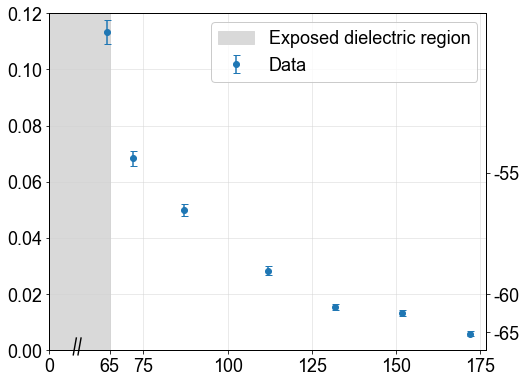

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "svg.fonttype": "none",
})

base_path = Path("Gen_1_Paper")
if not (base_path / "intensity_gaussian_fit_extracted.csv").exists():
    base_path = Path(".")
meas_data = np.loadtxt(base_path / "intensity_455nm_data_extracted.csv", delimiter=",", skiprows=1)

edge_x = 65.0
exposed_display_width_um = 18.0
ref_intensity = 0.02
ref_crosstalk_db = -60.0
data_color = "#1f77b4"

def compress_x(x):
    x = np.asarray(x, dtype=float)
    return np.where(
        x <= edge_x,
        x / edge_x * exposed_display_width_um,
        exposed_display_width_um + (x - edge_x),
    )

def crosstalk_db_to_intensity(db):
    return ref_intensity * 10 ** ((db - ref_crosstalk_db) / 10)

fig, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)

cutout = ax.axvspan(0, exposed_display_width_um, color="0.85", label="cutout region", zorder=0)
# edge_line = ax.axvline(edge_x, color="black", ls="--", lw=1.5,
#                        label="dielectric edge", zorder=2)
err = ax.errorbar(
    compress_x(meas_data[:, 0]), meas_data[:, 1],
    yerr=[meas_data[:, 2], meas_data[:, 3]],
    fmt="o", color=data_color, ecolor=data_color,
    elinewidth=1.5, capsize=3.5, ms=6,
    label="455 nm data", zorder=4,
)

x_ticks = np.array([0, 65, 75, 100, 125, 150, 175])
ax.set_xlim(0, compress_x(176.9))
ax.set_ylim(0, 0.12)
# ax.set_xlabel(r"Ion position [$\mu$m]")
# ax.set_ylabel(r"Intensity [mW/cm$^2$]")
ax.set_xticks(compress_x(x_ticks))
ax.set_xticklabels([f"{tick:g}" for tick in x_ticks])
ax.set_yticks(np.arange(0, 0.121, 0.02))
ax.grid(True, color="0.82", linewidth=0.8, alpha=0.55)

break_x = compress_x(30.0)
for offset in [-0.7, 0.7]:
    ax.plot(
        [break_x + offset - 0.45, break_x + offset + 0.45],
        [-0.015, 0.035],
        transform=ax.get_xaxis_transform(),
        color="black",
        lw=1.4,
        clip_on=False,
        zorder=5,
    )

ax_db = ax.twinx()
ax_db.set_ylim(ax.get_ylim())
db_ticks = np.array([-65, -60, -55])
ax_db.set_yticks(crosstalk_db_to_intensity(db_ticks))
ax_db.set_yticklabels([f"{tick:g}" for tick in db_ticks])
# ax_db.set_ylabel("Crosstalk [dB]")
ax_db.tick_params(axis="y", labelsize=18)

handles = [Rectangle((0, 0), 1, 1, color="0.85"), err]
labels = ["Exposed dielectric region", "Data"]
legend = ax.legend(handles, labels, loc="upper right", frameon=True)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("0.75")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)

fig.savefig(base_path / "intensity_extracted_plot.png", dpi=600)
fig.savefig(base_path / "intensity_extracted_plot.svg")
plt.show()


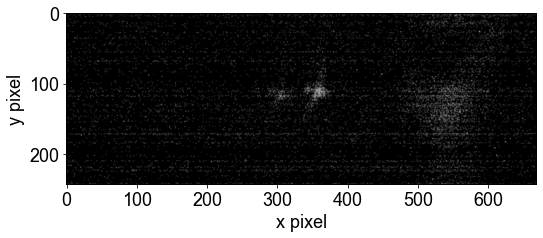

In [34]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "svg.fonttype": "none",
})

base_path = Path("Gen_1_Paper")
if not (base_path / "ca_indiv.tiff").exists():
    base_path = Path(".")

camera_img = mpimg.imread(base_path / "ca_indiv.tiff")

fig, ax = plt.subplots(figsize=(8.4, 3.2), constrained_layout=True)
ax.imshow(camera_img)
ax.set_xlabel("x pixel")
ax.set_ylabel("y pixel")
ax.tick_params(axis="both", labelsize=18)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)

fig.savefig(base_path / "ca_indiv_camera_image.png", dpi=300)
fig.savefig(base_path / "ca_indiv_camera_image.svg")
plt.show()


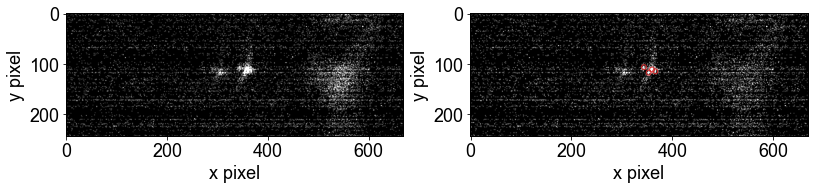

,label,area_pixels,x_centroid,y_centroid,integrated_background_subtracted,peak_background_subtracted,peak_intensity,x_min,x_max,y_min,y_max
0,1,76,359.938231,110.925948,8548.0,147.0,174.0,354,366,104,118
1,2,8,343.830787,106.303173,851.0,128.0,134.0,343,346,105,108
2,3,10,366.388836,114.632923,1057.0,132.0,151.0,365,367,112,117
3,4,10,353.150289,117.108863,1038.0,124.0,156.0,351,355,116,118


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "svg.fonttype": "none",
})

base_path = Path("Gen_1_Paper")
if not (base_path / "ca_indiv_digitized_arrays.npz").exists():
    base_path = Path(".")

data = np.load(base_path / "ca_indiv_digitized_arrays.npz")
intensity = data["intensity"]
bg_subtracted = data["background_subtracted"]
features = pd.read_csv(base_path / "ca_indiv_feature_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0), constrained_layout=True)

im0 = axes[0].imshow(intensity, cmap="gray", vmin=0, vmax=np.percentile(intensity, 99.8))
axes[0].set_xlabel("x pixel")
axes[0].set_ylabel("y pixel")

im1 = axes[1].imshow(bg_subtracted, cmap="gray", vmin=0, vmax=np.percentile(bg_subtracted, 99.8))
axes[1].scatter(features["x_centroid"], features["y_centroid"], s=24,
                facecolors="none", edgecolors="tab:red", linewidths=1.0)
axes[1].set_xlabel("x pixel")
axes[1].set_ylabel("y pixel")

for ax in axes:
    ax.tick_params(axis="both", labelsize=18)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

fig.savefig(base_path / "ca_indiv_digitized_diagnostic.png", dpi=300)
fig.savefig(base_path / "ca_indiv_digitized_diagnostic.svg")
plt.show()

features.head()


Default bright feature: x=359, y=110
Plotted y pixel: 113
Fit window: x=260..400 px = 0.00..12.60 um
Peak 1: shifted center=-5.056 um, original center=3.899 um (303.33 px), sigma=0.766 um, FWHM=1.803 um, amplitude=38.21
Peak 2: shifted center=0.000 um, original center=8.955 um (359.50 px), sigma=0.563 um, FWHM=1.325 um, amplitude=120.48
Baseline=3.51


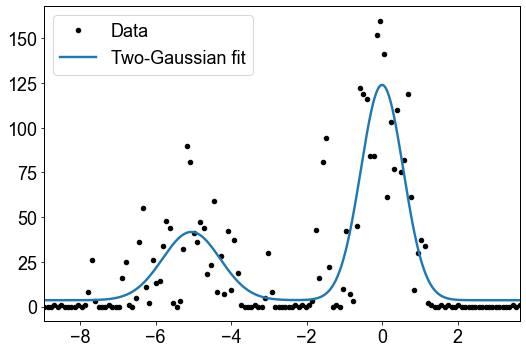

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, signal, optimize
from pathlib import Path

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "svg.fonttype": "none",
})

base_path = Path("Gen_1_Paper")
if not (base_path / "ca_indiv_digitized_arrays.npz").exists():
    base_path = Path(".")

data = np.load(base_path / "ca_indiv_digitized_arrays.npz")
intensity = data["intensity"]
bg_subtracted = data["background_subtracted"]
x_pixels = data["x_pixels"]

# Set this to an integer, e.g. selected_y_pixel = 110, to force a row.
# Leave as None to use the row through the brightest smoothed feature.
selected_y_pixel = 113
x_fit_min = 260
x_fit_max = 400
pixel_size_um = 0.09

smoothed = ndimage.gaussian_filter(bg_subtracted, sigma=2)
default_y_pixel, default_x_pixel = np.unravel_index(np.argmax(smoothed), smoothed.shape)
if selected_y_pixel is None:
    y_pixel = int(default_y_pixel)
else:
    y_pixel = int(np.clip(selected_y_pixel, 0, intensity.shape[0] - 1))

profile = intensity[y_pixel, :]
fit_mask = (x_pixels >= x_fit_min) & (x_pixels <= x_fit_max)
x_fit_pixel = x_pixels[fit_mask].astype(float)
x_fit_um = (x_fit_pixel - x_fit_pixel.min()) * pixel_size_um
y_fit = profile[fit_mask].astype(float)
y_smooth = ndimage.gaussian_filter1d(y_fit, sigma=2)

peaks, _ = signal.find_peaks(y_smooth, distance=20, prominence=10)
if len(peaks) < 2:
    peaks = np.argsort(y_smooth)[-2:]
peak_idx = np.sort(peaks[np.argsort(y_smooth[peaks])[-2:]])

baseline_guess = float(np.percentile(y_fit, 10))

def two_gaussian(x, baseline, amp1, center1, sigma1, amp2, center2, sigma2):
    g1 = amp1 * np.exp(-0.5 * ((x - center1) / sigma1) ** 2)
    g2 = amp2 * np.exp(-0.5 * ((x - center2) / sigma2) ** 2)
    return baseline + g1 + g2

p0 = [
    baseline_guess,
    max(float(y_smooth[peak_idx[0]] - baseline_guess), 1.0),
    float(x_fit_um[peak_idx[0]]),
    0.4,
    max(float(y_smooth[peak_idx[1]] - baseline_guess), 1.0),
    float(x_fit_um[peak_idx[1]]),
    0.4,
]
x_min_um = float(x_fit_um.min())
x_max_um = float(x_fit_um.max())
bounds = (
    [0, 0, x_min_um, 0.05, 0, x_min_um, 0.05],
    [255, 255, x_max_um, 3.0, 255, x_max_um, 3.0],
)
popt, pcov = optimize.curve_fit(two_gaussian, x_fit_um, y_fit, p0=p0, bounds=bounds, maxfev=50000)
baseline, amp1, center1, sigma1, amp2, center2, sigma2 = popt
x_dense_um = np.linspace(x_min_um, x_max_um, 1000)
total_fit = two_gaussian(x_dense_um, *popt)
fwhm1 = 2 * np.sqrt(2 * np.log(2)) * sigma1
fwhm2 = 2 * np.sqrt(2 * np.log(2)) * sigma2
center1_pixel = center1 / pixel_size_um + x_fit_pixel.min()
center2_pixel = center2 / pixel_size_um + x_fit_pixel.min()

x_axis_um = x_fit_um - center2
x_dense_axis_um = x_dense_um - center2

fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
ax.plot(x_axis_um, y_fit, "o", color="black", ms=4.5, label="Data")
ax.plot(x_dense_axis_um, total_fit, color="tab:blue", lw=2.4, label="Two-Gaussian fit")
# ax.set_xlabel(r"Position [$\mu$m]")
# ax.set_ylabel("Intensity [a.u.]")
ax.set_xlim(x_min_um - center2, x_max_um - center2)
ax.legend(loc="upper left", frameon=True)
ax.tick_params(axis="both", labelsize=18)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)

print(f"Default bright feature: x={int(default_x_pixel)}, y={int(default_y_pixel)}")
print(f"Plotted y pixel: {y_pixel}")
print(f"Fit window: x={x_fit_min}..{x_fit_max} px = {x_min_um:.2f}..{x_max_um:.2f} um")
print(f"Peak 1: shifted center={center1 - center2:.3f} um, original center={center1:.3f} um ({center1_pixel:.2f} px), sigma={sigma1:.3f} um, FWHM={fwhm1:.3f} um, amplitude={amp1:.2f}")
print(f"Peak 2: shifted center=0.000 um, original center={center2:.3f} um ({center2_pixel:.2f} px), sigma={sigma2:.3f} um, FWHM={fwhm2:.3f} um, amplitude={amp2:.2f}")
print(f"Baseline={baseline:.2f}")

fig.savefig(base_path / f"ca_indiv_intensity_profile_y{y_pixel}_gaussian_fit_um.png", dpi=300)
fig.savefig(base_path / f"ca_indiv_intensity_profile_y{y_pixel}_gaussian_fit_um.svg")
plt.show()
